# Running Validation Tests and Finding Relationships in IST DATA

## Imports

In [1]:
import pandas as pd
import numpy as np
import optuna
import jax.numpy as jnp
from tqdm.notebook import tqdm
import os


In [2]:
import sys
from pathlib import Path
# Add project root to path for imports
ROOT = Path.cwd().parent  
sys.path.append(str(ROOT))

from src.metrics.ist_analysis import (
    validate_ist_model,
    analyze_team_real_ist,
    analyze_team_sim_ist,
    analyze_player_def_rating,
    analyze_player_win_shares,
    analyze_game_real_ist,
    analyze_game_simulation_deviation,
    analyze_game_ist_vs_pts_allowed
)
from src.data_sources.nba_api_shots import fetch_league_shots_cached

In [3]:
%load_ext autoreload
%autoreload 2

In [5]:
fetch_league_shots_cached()

[*] Fetching 2015-16 League Shots from NBA API (Sneaking past firewall)...
[!] API Error: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=300)
[!] Retrying in 1.40s... (1/5)


KeyboardInterrupt: 

## Load Data

In [5]:
csv_path = '../data/processed/ist/all_plays_ist_master.csv'
ist_df = pd.read_csv(csv_path)

In [7]:
print(ist_df.shape)
ist_df.columns

(86597, 29)


Index(['Game_File', 'Play_Index', 'GAME_ID', 'SHOT_EVENT_ID',
       'Offensive_Team_ID', 'Defensive_Team_ID', 'Shooter_PID', 'Shot_Dist',
       'Is_Three', 'Real_IST', 'Sim_IST', 'Pressure_Prevented',
       'Efficiency_Gain_%', 'POS_Real_IST', 'POS_Sim_IST', 'Frames_Won',
       'Total_Frames', 'Frame_Win_Rate', 'Offender_1_PID', 'Defender_1_PID',
       'Offender_2_PID', 'Defender_2_PID', 'Offender_3_PID', 'Defender_3_PID',
       'Offender_4_PID', 'Defender_4_PID', 'Offender_5_PID', 'Defender_5_PID',
       'Shot_Made'],
      dtype='object')

## IST Analysis

### Does IST minimize Field Goal% ?

/Users/cadenp/Documents/GitHub/DSC180B_FinalProject/src/mectrics/ist_analysis.py:164: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Pressure_Tier', y='FG_Pct', palette='coolwarm')


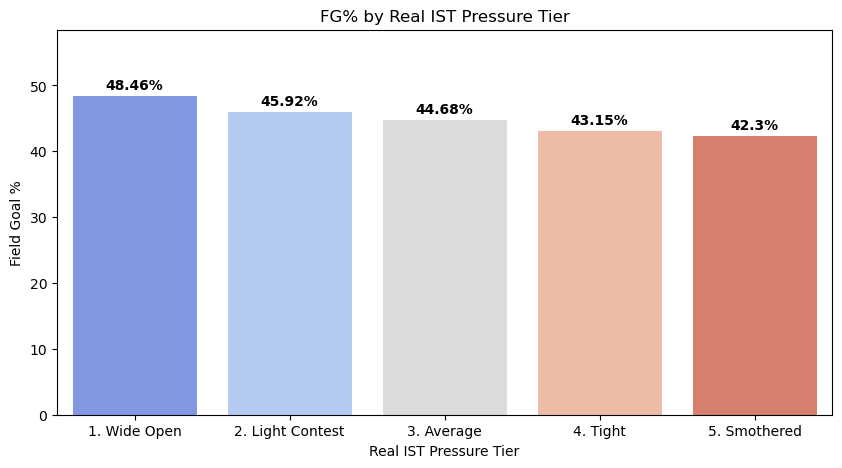

,Pressure_Tier,FG_Pct,Sample_Size
0,1. Wide Open,48.46,17322
1,2. Light Contest,45.92,17321
2,3. Average,44.68,17321
3,4. Tight,43.15,17318
4,5. Smothered,42.30,17315


In [9]:
validate_ist_model(csv_path)

### Does a team Minizmizing IST Correlate with Good Team Defense?

Loading ../data/raw/defense/nba_team_stats_2015-16.csv for Real IST validation...


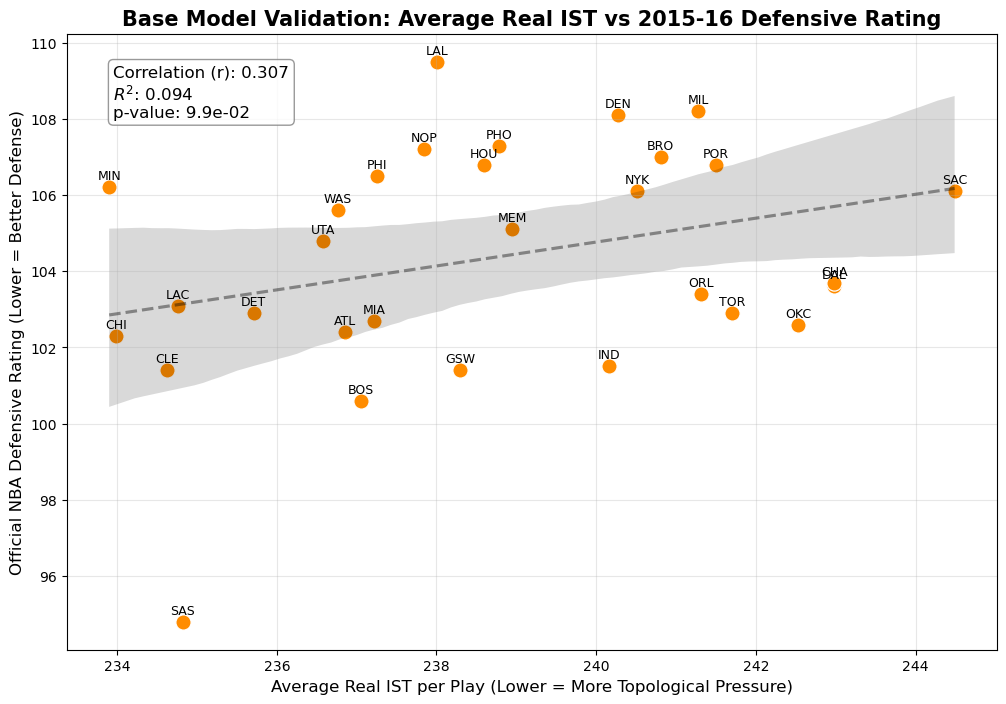

In [38]:
team_df = analyze_team_real_ist(csv_path)

### Can IST tell us how impactful a Defensive Player is?

Loading ../data/raw/defense/nba_player_stats_2015-16.csv for Real IST validation...


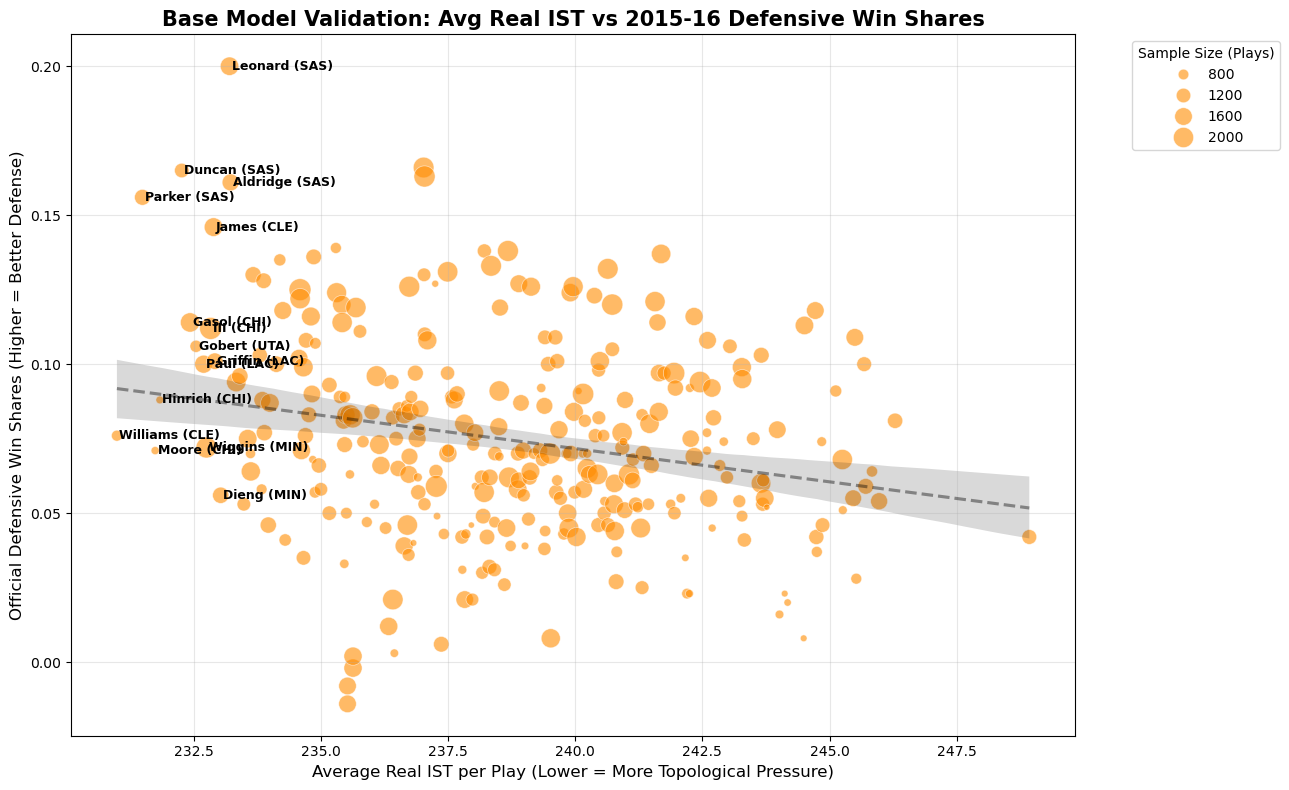

In [34]:
win_share_df = analyze_player_win_shares(csv_path)

Loading ../data/raw/defense/nba_player_stats_2015-16.csv for Real IST vs Def Rtg validation...


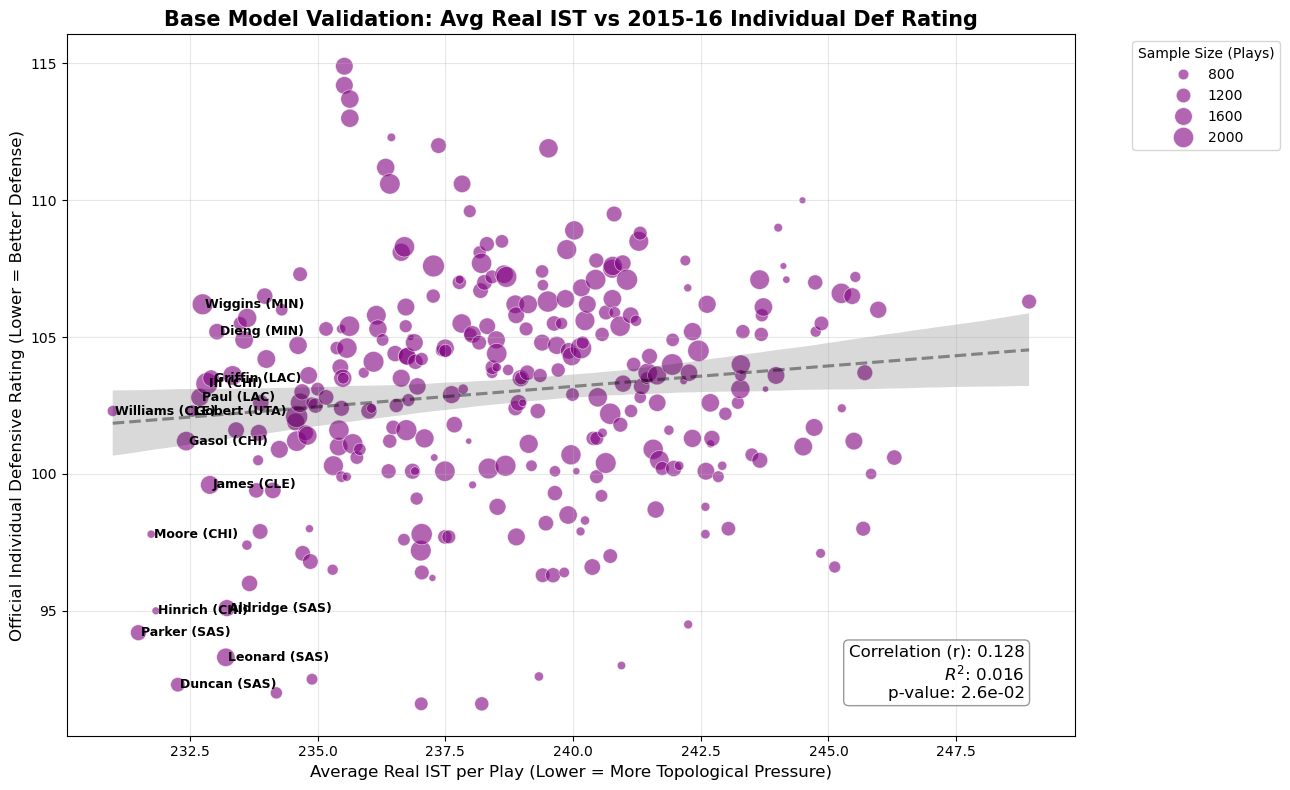

In [37]:
player_def_rating_df = analyze_player_def_rating()

### Can blowouts in Game be predicted from IST?

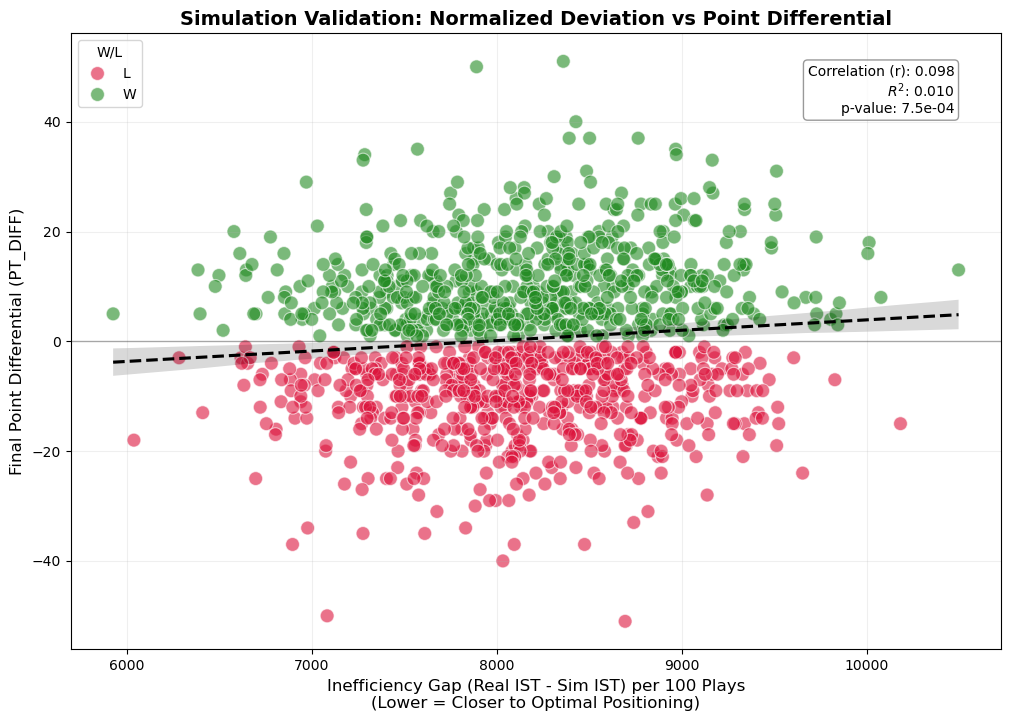

In [55]:
game_ist_df = analyze_game_simulation_deviation()

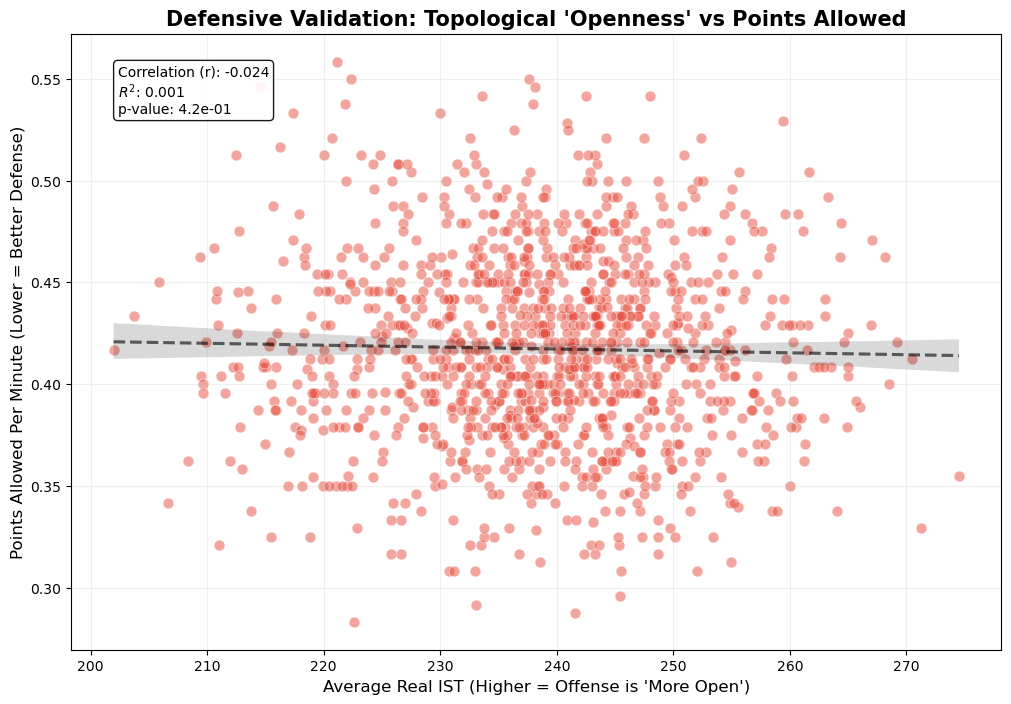

In [60]:
game_ist_df2 = analyze_game_ist_vs_pts_allowed()

In [64]:
game_score_df = pd.read_csv('../data/raw/defense/nba_game_scores_2015-16.csv')
game_score_df.shape[0]/2

661.0

In [31]:
import seaborn as sns
import plotly as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Circle, Rectangle, Arc, ConnectionPatch
def plot_ist_population_shift(summary_df, filename="ist_distribution_shift_final.png"):
    plt.style.use('default')
    # NBA Colors: Grey (Real), Navy (Sim), Red (Highlight)
    C_REAL, C_SIM, C_BG, C_OFF = '#888888', '#1D428A', '#BEC0C2', '#C8102E'
    
    # 1. Stats Calculation
    real_mean = summary_df['Real_IST'].mean()
    sim_mean = summary_df['Sim_IST'].mean()
    # Using your specific calculated stats
    win_rate = 97.12  
    efficiency_gain = 39.39 

    fig, ax = plt.subplots(figsize=(14, 9), dpi=300)
    fig.patch.set_facecolor(C_BG); fig.patch.set_alpha(0.15); ax.set_facecolor('none')
    
    # 2. Population Distributions
    sns.kdeplot(summary_df['Real_IST'], fill=True, color=C_REAL, 
                lw=6, label='Historical NBA Defense', alpha=0.3, ax=ax)
    sns.kdeplot(summary_df['Sim_IST'], fill=True, color=C_SIM, 
                lw=6, label='JKO Simulated Defense', alpha=0.5, ax=ax)
    
    # 3. Mean Reference Lines
    ax.axvline(real_mean, color=C_REAL, ls=':', lw=4, alpha=0.8)
    ax.axvline(sim_mean, color=C_SIM, ls=':', lw=4, alpha=0.8)

    # 4. Global Threat Reduction Arrow
    y_limit = ax.get_ylim()[1]
    arrow_y = y_limit * 0.40 
    ax.annotate('', xy=(sim_mean, arrow_y), xytext=(real_mean, arrow_y),
                arrowprops=dict(arrowstyle='<->', color=C_OFF, lw=5))
    ax.text((real_mean + sim_mean)/2, arrow_y + (y_limit * 0.03), "THREAT REDUCTION", 
            color=C_OFF, fontweight='black', fontsize=16, ha='center')

    # 5. Labels & Title
    ax.set_title("Global Defensive Threat Distribution", fontsize=32, fontweight='black', 
                 pad=60, color=C_SIM, loc='center')
    ax.set_xlabel("Mean Team IST Per Possession", fontsize=20, fontweight='bold', labelpad=20)
    ax.set_ylabel("Frequency Density", fontsize=20, fontweight='bold', labelpad=20)
    
    # 6. Combined Performance Dashboard (Top Right)
    leg = ax.legend(fontsize=16, loc='upper right', frameon=True, shadow=True, 
                    facecolor='white', edgecolor=C_SIM, borderpad=1.2)

    stats_text = (f"GLOBAL WIN RATE: {win_rate}%\n"
                        f"THREAT REDUCTION: 51.73%")
    
    ax.text(0.97, 0.65, stats_text, transform=ax.transAxes,
            fontsize=18, fontweight='black', color='white', 
            ha='right', va='top',
            bbox=dict(boxstyle="round,pad=1.0", facecolor=C_OFF, edgecolor='none'))

    # 7. Polish Spines
    for s in ['top', 'right']: ax.spines[s].set_visible(False)
    for s in ['left', 'bottom']:
        ax.spines[s].set_color(C_SIM); ax.spines[s].set_linewidth(3)
    
    plt.tight_layout()
    plt.savefig(filename, facecolor=fig.get_facecolor())
    plt.show()

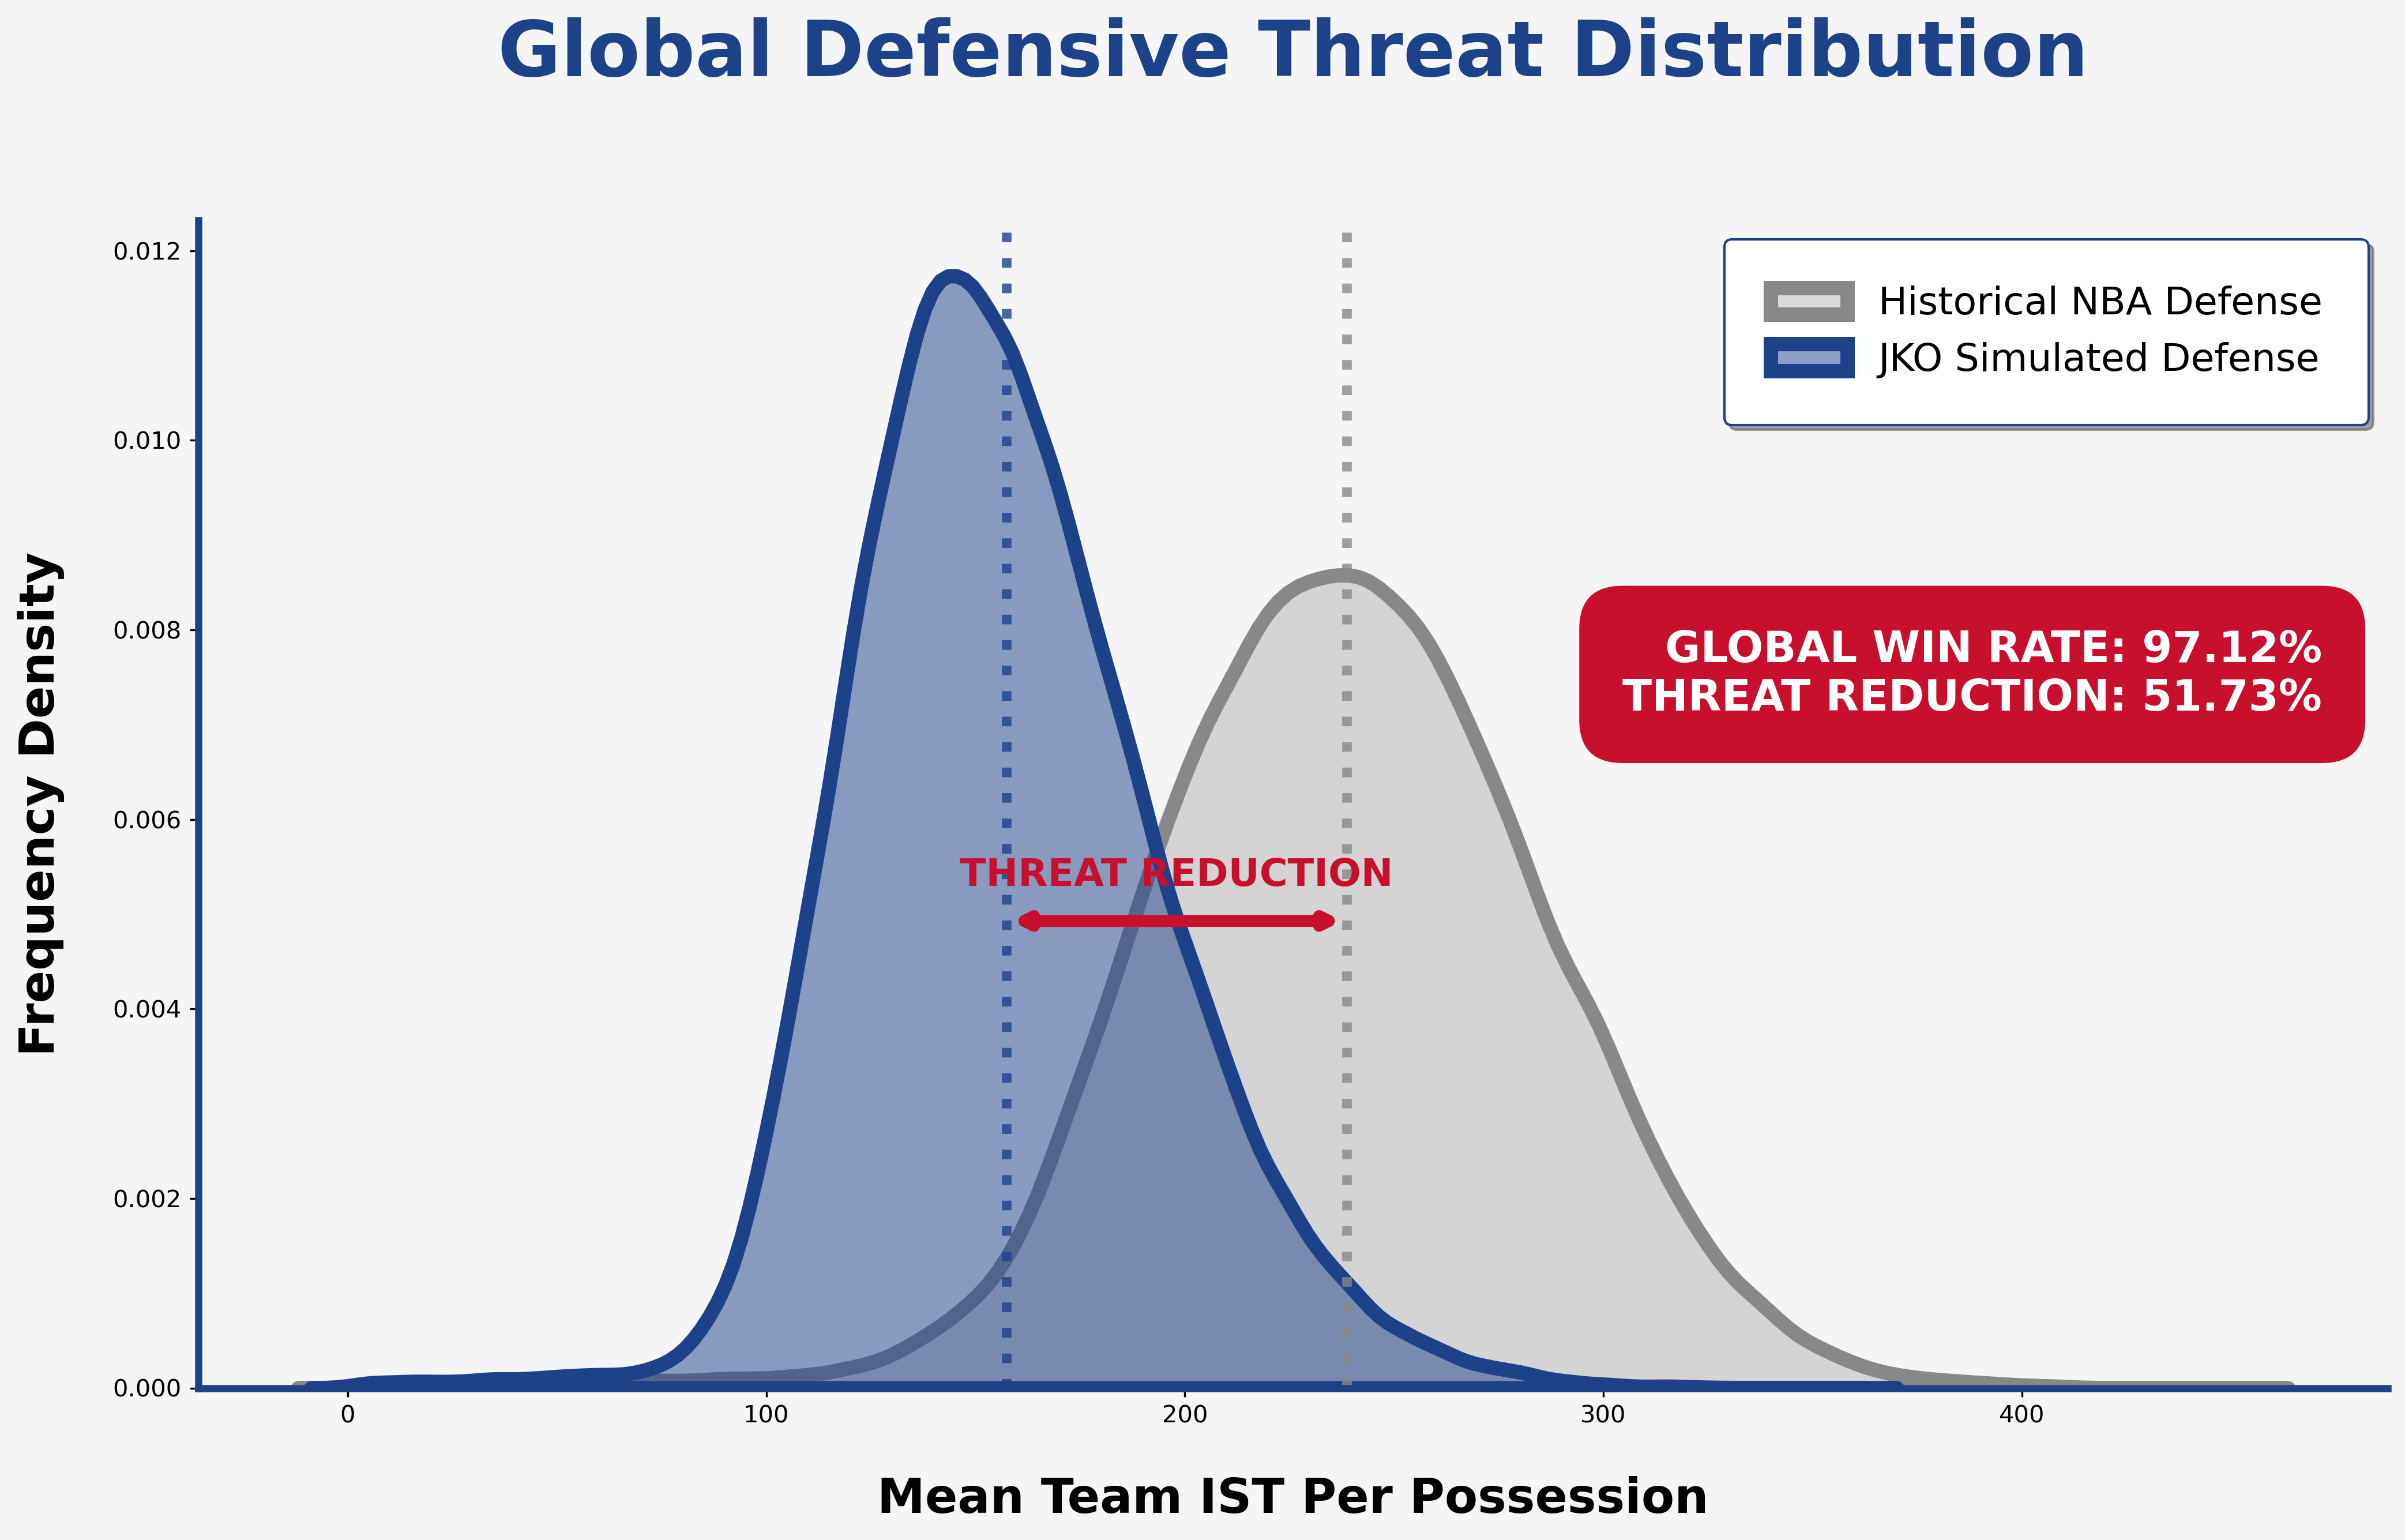

In [32]:
plot_ist_population_shift(ist_df)

In [13]:
ist_df['Real_IST'].mean()/ist_df['Sim_IST'].mean()

np.float64(1.5173329476090094)

In [15]:
ist_df['Frames_Won'].sum()/ist_df['Total_Frames'].sum()

np.float64(0.9711576406534591)

In [6]:
threat_threshold = ist_df['Real_IST'].quantile(0.90)
high_threat_df = ist_df[ist_df['Real_IST'] > threat_threshold]
median_recovery_gap = (high_threat_df['Real_IST'] - high_threat_df['Sim_IST']).median()
median_pct_gain = high_threat_df['Efficiency_Gain_%'].median()

print(f"High-Threat Threshold (90th percentile): {threat_threshold:.4f}")
print(f"Median Recovery Gap in High-Threat Plays: {median_recovery_gap:.4f}")
print(f"Median Efficiency Gain: {median_pct_gain:.2f}%")

High-Threat Threshold (90th percentile): 298.1600
Median Recovery Gap in High-Threat Plays: 125.7500
Median Efficiency Gain: 39.39%


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Figure 1: Frame Win Rate Distribution ---
def plot_frame_win_rate(df):
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Frame_Win_Rate'], bins=30, kde=True, color='skyblue', edgecolor='black')
    
    # Add Mean Line for clarity
    mean_val = df['Frame_Win_Rate'].mean()
    plt.axvline(mean_val, color='red', linestyle='--', label=f"Mean: {mean_val:.2%}")
    
    plt.title('Distribution of Frame Win Rates Across All Possessions', fontsize=14)
    plt.xlabel('Frame Win Rate (Simulated IST < Real IST)', fontsize=12)
    plt.ylabel('Frequency (Number of Possessions)', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('frame_win_rate_dist.png', dpi=300)
    plt.show()

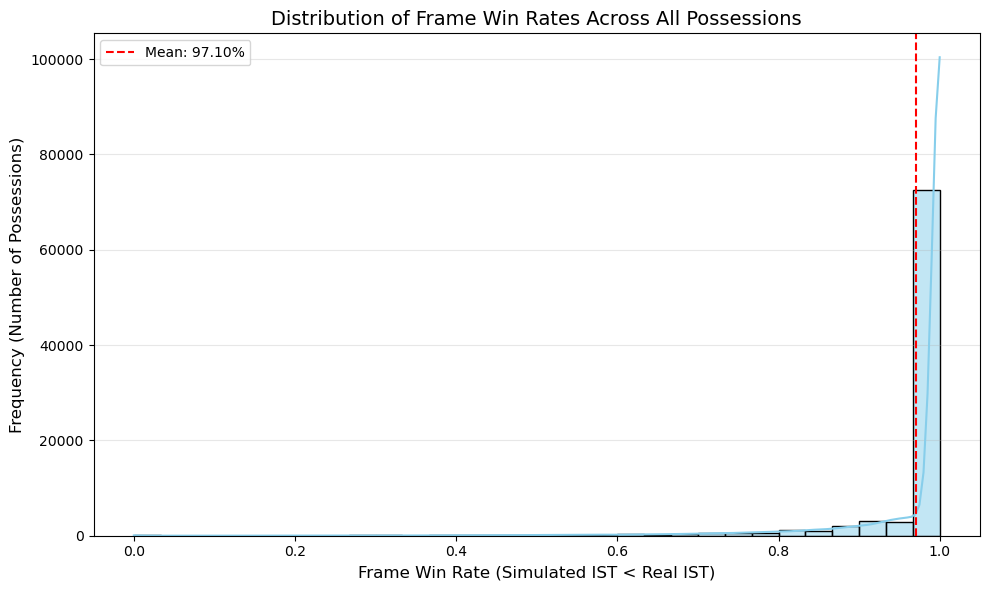

In [26]:
plot_frame_win_rate(ist_df)

In [ ]:
def plot_recovery_timeline(single_possession_df):
    """
    Expects a DataFrame with 'Frame', 'Real_IST', and 'Sim_IST' for one play.
    """
    plt.figure(figsize=(12, 6))
    
    # Plotting both lines
    plt.plot(single_possession_df['Frame'], single_possession_df['Real_IST'], 
             label='Real NBA IST (Baseline)', color='#e74c3c', linewidth=2, marker='o', alpha=0.8)
    plt.plot(single_possession_df['Frame'], single_possession_df['Sim_IST'], 
             label='JKO Simulated IST', color='#3498db', linewidth=2, marker='s', alpha=0.8)
    
    # Shading the Recovery Gap
    plt.fill_between(single_possession_df['Frame'], 
                     single_possession_df['Sim_IST'], 
                     single_possession_df['Real_IST'], 
                     where=(single_possession_df['Real_IST'] > single_possession_df['Sim_IST']), 
                     color='gray', alpha=0.2, label='Recovery Gap')
    
    plt.title('Temporal IST Recovery Comparison: Case Study of a High-Threat Possession', fontsize=14)
    plt.xlabel('Time (Frames)', fontsize=12)
    plt.ylabel('Team Instantaneous Shot Threat (IST)', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('recovery_timeline.png', dpi=300)
    plt.show()